# Часть 2

- оптимизаторы **SGD** и **Adam**;
- **мультирегрессия** (FCNN + BatchNorm + Dropout + **три** размера сети + разные активации) + **Diabetes (sklearn)**;
- **Fashion-MNIST (OpenML)**: свёртки, пулы, `Flatten`, **LogSoftMax + NLL** и отдельно **SoftMax + unstable NLL**;
- **автоэнкодер** на свёртках и FC, **Dropout**, **PSNR**;
- **косинусный lr** после **warmup**, **early stopping**, **чекпоинты** `.npz`, **смена** оптимизатора (и в регрессии ещё **смена лосса** MSE→MAE).

Нужны `scikit-learn` и доступ в интернет для загрузки Fashion-MNIST (OpenML).


In [2]:
import pathlib
import json
import copy
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_regression, load_diabetes
from sklearn.preprocessing import StandardScaler

ROOT = pathlib.Path.cwd()
MODULES_NB = ROOT / "homework_modules1212121212_1.ipynb"
ns = {"np": np, "numpy": np}
for cell in json.loads(MODULES_NB.read_text(encoding="utf-8"))["cells"]:
    if cell.get("cell_type") != "code":
        continue
    src = "".join(cell.get("source", []))
    if not src.strip() or src.strip().startswith("%run"):
        continue
    exec(compile(src, str(MODULES_NB), "exec"), ns)
for _k, _v in ns.items():
    if _k.startswith("_"):
        continue
    globals()[_k] = _v

print("Загружены слои из:", MODULES_NB.name)


Загружены слои из: homework_modules1212121212_1.ipynb


In [3]:
def walk_param_grad_pairs(params, grads):
    out = []

    def rec(p, g):
        if isinstance(p, list):
            for pi, gi in zip(p, g):
                rec(pi, gi)
        else:
            out.append((p, g))

    rec(params, grads)
    return out


def zeros_like_nested(params):
    if isinstance(params, list):
        return [zeros_like_nested(p) for p in params]
    return np.zeros_like(params)


class SGD:
    "Стохастический градиентный спуск с импульсом"

    def __init__(self, model, lr=0.01, momentum=0.0, weight_decay=0.0):
        self.model = model
        self.lr = lr
        self.momentum = momentum
        self.weight_decay = weight_decay
        self.velocity = None

    def step(self):
        params = self.model.getParameters()
        grads = self.model.getGradParameters()
        if self.velocity is None:
            self.velocity = zeros_like_nested(params)

        def apply_vel(pn, gn, vn):
            if isinstance(pn, list):
                for p, g, v in zip(pn, gn, vn):
                    apply_vel(p, g, v)
            else:
                g_eff = gn + self.weight_decay * pn
                vn[:] = self.momentum * vn + g_eff
                pn -= self.lr * vn

        apply_vel(params, grads, self.velocity)


class Adam:
    "Adam (Kingma & Ba)"

    def __init__(self, model, lr=1e-3, betas=(0.9, 0.999), eps=1e-8, weight_decay=0.0):
        self.model = model
        self.lr = lr
        self.beta1, self.beta2 = betas
        self.eps = eps
        self.weight_decay = weight_decay
        self.t = 0
        self.m = None
        self.v = None

    def step(self):
        self.t += 1
        if self.m is None:
            self.m = zeros_like_nested(self.model.getParameters())
            self.v = zeros_like_nested(self.model.getParameters())

        def update(p_node, g_node, m_node, v_node):
            if isinstance(p_node, list):
                for p, g, m, v in zip(p_node, g_node, m_node, v_node):
                    update(p, g, m, v)
            else:
                g_eff = g_node + self.weight_decay * p_node
                m_node[:] = self.beta1 * m_node + (1.0 - self.beta1) * g_eff
                v_node[:] = self.beta2 * v_node + (1.0 - self.beta2) * (g_eff * g_eff)
                m_hat = m_node / (1.0 - self.beta1**self.t)
                v_hat = v_node / (1.0 - self.beta2**self.t)
                p_node -= self.lr * m_hat / (np.sqrt(v_hat) + self.eps)

        update(
            self.model.getParameters(),
            self.model.getGradParameters(),
            self.m,
            self.v,
        )


def lr_cosine_with_warmup(step, base_lr, warmup_steps, total_steps, min_lr=0.0):
    "Косинусный decay после линейного warmup"
    if step < warmup_steps:
        return base_lr * float(step + 1) / float(max(1, warmup_steps))
    progress = float(step - warmup_steps) / float(max(1, total_steps - warmup_steps))
    progress = min(1.0, max(0.0, progress))
    return min_lr + 0.5 * (base_lr - min_lr) * (1.0 + np.cos(np.pi * progress))


def train_batch(model, x, y, criterion, optimizer):
    model.zeroGradParameters()
    pred = model.forward(x)
    loss = criterion.forward(pred, y)
    grad = criterion.backward(pred, y)
    model.backward(x, grad)
    optimizer.step()
    return float(loss)


def copy_flat_params(model):
    flat = []

    def rec(p):
        if isinstance(p, list):
            for x in p:
                rec(x)
        else:
            flat.append(np.copy(p))

    rec(model.getParameters())
    return flat


def load_flat_params(model, flat):
    it = iter(flat)

    def rec(p):
        if isinstance(p, list):
            for x in p:
                rec(x)
        else:
            n = next(it)
            p[...] = n

    rec(model.getParameters())


def evaluate_regression(model, x, y, criterion):
    was_training = model.training
    model.evaluate()
    pred = model.forward(x)
    loss = float(criterion.forward(pred, y))
    mae = float(np.mean(np.abs(pred - y)))
    ss_res = float(np.sum((y - pred) ** 2))
    ss_tot = float(np.sum((y - np.mean(y, axis=0, keepdims=True)) ** 2))
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 1e-12 else 0.0
    if was_training:
        model.train()
    return loss, mae, r2


def evaluate_classification_logits(model, x, y, criterion):
    "y — индексы классов; pred — log-softmax."
    was_training = model.training
    model.evaluate()
    pred = model.forward(x)
    y_oh = np.zeros((len(y), pred.shape[1]), dtype=pred.dtype)
    y_oh[np.arange(len(y)), y] = 1.0
    loss = float(criterion.forward(pred, y_oh))
    acc = float(np.mean(np.argmax(pred, axis=1) == y))
    if was_training:
        model.train()
    return loss, acc


def evaluate_ae(model, x, criterion):
    was_training = model.training
    model.evaluate()
    pred = model.forward(x)
    loss = float(criterion.forward(pred, x))
    if was_training:
        model.train()
    return loss


class EarlyStopping:
    def __init__(self, patience=8, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best = None
        self.bad_epochs = 0

    def is_better(self, val):
        if self.best is None or val < self.best - self.min_delta:
            self.best = val
            self.bad_epochs = 0
            return True
        self.bad_epochs += 1
        return False

    def should_stop(self):
        return self.bad_epochs >= self.patience


class MAECriterion:
    """MAE по батчу: mean(|pred - target|), градиент согласован с делением на batch."""

    def __init__(self):
        self.output = None
        self.gradInput = None

    def forward(self, input, target):
        return float(self.updateOutput(input, target))

    def backward(self, input, target):
        return self.updateGradInput(input, target)

    def updateOutput(self, input, target):
        self.output = float(np.mean(np.abs(input - target)))
        return self.output

    def updateGradInput(self, input, target):
        self.gradInput = np.sign(input - target) / float(input.shape[0])
        return self.gradInput


In [4]:
class Sigmoid(Module):
    def updateOutput(self, input):
        x = np.clip(input, -500, 500)
        self.output = 1.0 / (1.0 + np.exp(-x))
        return self.output

    def updateGradInput(self, input, gradOutput):
        s = self.output
        self.gradInput = gradOutput * s * (1.0 - s)
        return self.gradInput

    def __repr__(self):
        return "Sigmoid"


class Reshape(Module):
    def __init__(self, *shape):
        super().__init__()
        self.shape = shape

    def updateOutput(self, input):
        self._in_shape = input.shape
        self.output = input.reshape(input.shape[0], *self.shape)
        return self.output

    def updateGradInput(self, input, gradOutput):
        self.gradInput = gradOutput.reshape(self._in_shape)
        return self.gradInput

    def __repr__(self):
        return "Reshape" + str(self.shape)


class NearestUpsample2d(Module):
    def __init__(self, scale_factor):
        super().__init__()
        self.s = int(scale_factor)

    def updateOutput(self, input):
        s = self.s
        self.output = np.repeat(np.repeat(input, s, axis=2), s, axis=3)
        return self.output

    def updateGradInput(self, input, gradOutput):
        N, C, H, W = input.shape
        s = self.s
        g = gradOutput.reshape(N, C, H, s, W, s).sum(axis=(3, 5))
        self.gradInput = g
        return self.gradInput

    def __repr__(self):
        return "NearestUpsample2d"


In [5]:
def build_fc_regression(n_in, n_out, hidden, p_drop, act_ctor):
    """Полносвязная сеть: Linear → BN → масштаб по каналам → активация → Dropout → …"""
    net = Sequential()
    prev = n_in
    for h in hidden:
        net.add(Linear(prev, h))
        net.add(BatchNormalization(alpha=0.9))
        net.add(ChannelwiseScaling(h))
        net.add(act_ctor())
        net.add(Dropout(p_drop))
        prev = h
    net.add(Linear(prev, n_out))
    return net


def save_checkpoint_npz(path, model):
    flat = copy_flat_params(model)
    np.savez_compressed(str(path), *flat)


def load_checkpoint_npz(path, model):
    z = np.load(path)
    flat = [z[k] for k in sorted(z.files)]
    load_flat_params(model, flat)


def run_regression_experiment(
    name,
    model,
    X_tr,
    y_tr,
    X_va,
    y_va,
    X_te,
    y_te,
    criterion,
    base_lr,
    epochs,
    batch_size,
    warmup_steps,
    early,
    optimizer_ctor,
    switch_epoch=None,
    switch_optimizer_ctor=None,
    switch_criterion=None,
    early_on="loss",
    checkpoint_path=None,
):
    opt = optimizer_ctor(model)
    crit = criterion
    history = {"train_loss": [], "val_loss": [], "val_mae": [], "val_r2": [], "lr": []}
    total_steps = max(1, epochs * (len(X_tr) // batch_size))
    step = 0
    best_state = None
    es = EarlyStopping(patience=early, min_delta=1e-5)

    for ep in range(epochs):
        if switch_epoch is not None and ep == switch_epoch and switch_optimizer_ctor is not None:
            opt = switch_optimizer_ctor(model)
            if switch_criterion is not None:
                crit = switch_criterion
            es = EarlyStopping(patience=early, min_delta=1e-5)
            print(f"  [{name}] смена оптимизатора/лосса, эпоха {ep}")

        perm = np.random.permutation(len(X_tr))
        Xs, ys = X_tr[perm], y_tr[perm]
        tr_losses = []
        for i in range(0, len(Xs), batch_size):
            xb = Xs[i : i + batch_size]
            yb = ys[i : i + batch_size]
            lr_now = lr_cosine_with_warmup(step, base_lr, warmup_steps, total_steps)
            opt.lr = lr_now
            tr_losses.append(train_batch(model, xb, yb, crit, opt))
            step += 1
        vl, mae, r2 = evaluate_regression(model, X_va, y_va, crit)
        history["train_loss"].append(float(np.mean(tr_losses)))
        history["val_loss"].append(vl)
        history["val_mae"].append(mae)
        history["val_r2"].append(r2)
        history["lr"].append(opt.lr)
        monitor = vl if early_on == "loss" else -r2
        if es.is_better(monitor):
            best_state = copy_flat_params(model)
            if checkpoint_path is not None:
                save_checkpoint_npz(checkpoint_path, model)
        if es.should_stop():
            print(f"  [{name}] early stopping, эпоха {ep}")
            break

    if best_state is not None:
        load_flat_params(model, best_state)
    te_loss, te_mae, te_r2 = evaluate_regression(model, X_te, y_te, crit)
    return history, {"test_loss": te_loss, "test_mae": te_mae, "test_r2": te_r2}


### 1. Мультирегрессия (синтетика)

Три размера сети; параметры `make_regression` и сплиты отличаются от «шаблонных» 4000×16×4.


Обучение small_relu [56, 28]
  [small_relu] смена оптимизатора/лосса, эпоха 14
  тест: {'test_loss': 0.13926562657961347, 'test_mae': 0.13926562657961347, 'test_r2': 0.969720331251741}
Обучение medium_leaky [144, 72]
  [medium_leaky] смена оптимизатора/лосса, эпоха 14
  тест: {'test_loss': 0.08241389764367577, 'test_mae': 0.08241389764367577, 'test_r2': 0.9897946694734231}
Обучение large_elu [288, 144, 72]
  [large_elu] смена оптимизатора/лосса, эпоха 14
  тест: {'test_loss': 0.07189687183490351, 'test_mae': 0.07189687183490351, 'test_r2': 0.9920593277378252}


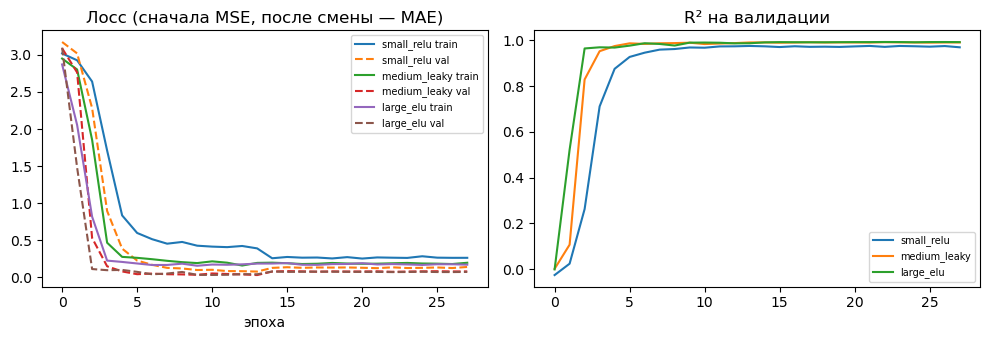

In [6]:
# --- 1) Мультирегрессия (синтетика sklearn): другие размерности и сиды ---
CKPT_DIR = ROOT / "checkpoints"
CKPT_DIR.mkdir(exist_ok=True)

np.random.seed(17)
X, y = make_regression(
    n_samples=2400,
    n_features=18,
    n_targets=3,
    noise=15.0,
    bias=3.8,
    random_state=17,
)
y = y.astype(np.float32)
sc_x = StandardScaler()
sc_y = StandardScaler()
X = sc_x.fit_transform(X).astype(np.float32)
y = sc_y.fit_transform(y).astype(np.float32)

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.28, random_state=11)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=19)

configs = [
    ("small_relu", [56, 28], lambda: ReLU()),
    ("medium_leaky", [144, 72], lambda: LeakyReLU(0.01)),
    ("large_elu", [288, 144, 72], lambda: ELU(1.0)),
]

reg_results = {}
EPOCHS_REG = 28
BATCH = 64
WARM = 150
SW = 14
N_IN, N_OUT = 18, 3
for tag, hidden, act_ctor in configs:
    print("Обучение", tag, hidden)
    m = build_fc_regression(N_IN, N_OUT, hidden, 0.25, act_ctor)
    m.train()
    hist, test_m = run_regression_experiment(
        tag,
        m,
        X_train,
        y_train,
        X_val,
        y_val,
        X_test,
        y_test,
        MSECriterion(),
        base_lr=3e-3,
        epochs=EPOCHS_REG,
        batch_size=BATCH,
        warmup_steps=WARM,
        early=8,
        optimizer_ctor=lambda mod: Adam(mod, lr=3e-3),
        switch_epoch=SW,
        switch_optimizer_ctor=lambda mod: SGD(mod, lr=5e-2, momentum=0.85),
        switch_criterion=MAECriterion(),
        early_on="loss",
        checkpoint_path=CKPT_DIR / ("reg_" + tag + ".npz"),
    )
    reg_results[tag] = (hist, test_m)
    print("  тест:", test_m)

fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
for tag, (hist, _) in reg_results.items():
    ax[0].plot(hist["train_loss"], label=f"{tag} train")
    ax[0].plot(hist["val_loss"], "--", label=f"{tag} val")
ax[0].set_title("Лосс (сначала MSE, после смены — MAE)")
ax[0].set_xlabel("эпоха")
ax[0].legend(fontsize=7)
for tag, (hist, _) in reg_results.items():
    ax[1].plot(hist["val_r2"], label=tag)
ax[1].set_title("R² на валидации")
ax[1].legend(fontsize=7)
plt.tight_layout()
plt.show()


### 1b. Реальные данные: Diabetes (sklearn)

Встроенный датасет `load_diabetes`: 10 признаков, один непрерывный таргет. Другие числа и кривые, чем у типовой синтетики из учебников.


  [diabetes_sklearn] early stopping, эпоха 14
Diabetes тест: {'test_loss': 0.6099651294288899, 'test_mae': 0.6551277247695283, 'test_r2': 0.4231902617031954}


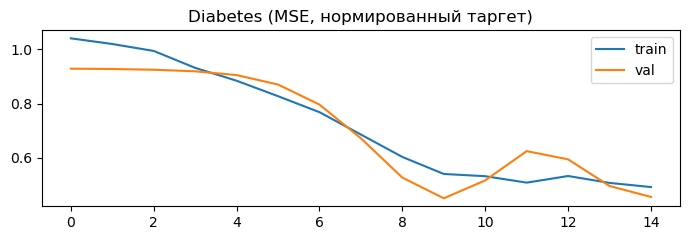

In [7]:
# --- 1b) Реальные данные: Diabetes (встроенный датасет sklearn) ---

dia = load_diabetes()
X_d = dia.data.astype(np.float32)
y_d = dia.target.astype(np.float32).reshape(-1, 1)
sc_x_d = StandardScaler()
sc_y_d = StandardScaler()
X_d = sc_x_d.fit_transform(X_d).astype(np.float32)
y_d = sc_y_d.fit_transform(y_d).astype(np.float32)
X_d_tr, X_d_temp, y_d_tr, y_d_temp = train_test_split(
    X_d, y_d, test_size=0.22, random_state=41
)
X_d_va, X_d_te, y_d_va, y_d_te = train_test_split(
    X_d_temp, y_d_temp, test_size=0.5, random_state=53
)

m_diabetes = build_fc_regression(X_d.shape[1], 1, [80, 40], 0.18, lambda: Gelu())
m_diabetes.train()
hist_d, test_d = run_regression_experiment(
    "diabetes_sklearn",
    m_diabetes,
    X_d_tr,
    y_d_tr,
    X_d_va,
    y_d_va,
    X_d_te,
    y_d_te,
    MSECriterion(),
    base_lr=1e-2,
    epochs=22,
    batch_size=96,
    warmup_steps=80,
    early=5,
    optimizer_ctor=lambda mod: Adam(mod, lr=1e-2),
    early_on="loss",
    checkpoint_path=CKPT_DIR / "reg_diabetes_sklearn.npz",
)
print("Diabetes тест:", test_d)
plt.figure(figsize=(7, 2.5))
plt.plot(hist_d["train_loss"], label="train")
plt.plot(hist_d["val_loss"], label="val")
plt.title("Diabetes (MSE, нормированный таргет)")
plt.legend()
plt.tight_layout()
plt.show()


### 2. Классификация Fashion-MNIST

28×28, 10 классов (одежда/обувь), OpenML. CNN та же по форме, что для MNIST.


In [ ]:
# --- 2) Fashion-MNIST (OpenML): CNN + LogSoftMax + NLL; затем SoftMax + unstable NLL ---
try:
    from sklearn.datasets import fetch_openml
    fmnist = fetch_openml(
        name="Fashion-MNIST",
        version=1,
        as_frame=False,
        parser="liac-arff",
    )
    Xm = fmnist["data"].astype(np.float32) / 255.0
    ym = np.asarray(fmnist["target"], dtype=np.int64)
except Exception as e:
    print("OpenML Fashion-MNIST:", e)
    raise

X_m = Xm.reshape(-1, 1, 28, 28)
y_m = ym
X_tr, X_temp, y_tr, y_temp = train_test_split(X_m, y_m, test_size=0.3, random_state=17)
X_va, X_te, y_va, y_te = train_test_split(X_temp, y_temp, test_size=0.5, random_state=29)


def one_hot(y, c):
    o = np.zeros((len(y), c), dtype=np.float32)
    o[np.arange(len(y)), y] = 1.0
    return o


def train_clf_epoch(model, X, y, crit, opt, batch, step_ref, base_lr, warmup_steps, total_steps):
    model.train()
    perm = np.random.permutation(len(X))
    losses = []
    for i in range(0, len(X), batch):
        xb = X[perm[i : i + batch]]
        yb = y[perm[i : i + batch]]
        yb_oh = one_hot(yb, 10)
        opt.lr = lr_cosine_with_warmup(step_ref[0], base_lr, warmup_steps, total_steps)
        model.zeroGradParameters()
        pred = model.forward(xb)
        loss = crit.forward(pred, yb_oh)
        g = crit.backward(pred, yb_oh)
        model.backward(xb, g)
        opt.step()
        step_ref[0] += 1
        losses.append(loss)
    return float(np.mean(losses))


def build_fashion_cnn(use_softmax=False):
    net = Sequential()
    net.add(Conv2d(1, 16, 3, padding="same", padding_mode="zeros"))
    net.add(ReLU())
    net.add(MaxPool2d(2, 2, 0))
    net.add(Conv2d(16, 32, 3, padding="same", padding_mode="zeros"))
    net.add(ReLU())
    net.add(MaxPool2d(2, 2, 0))
    net.add(Flatten(1, -1))
    net.add(Linear(32 * 7 * 7, 128))
    net.add(BatchNormalization(alpha=0.9))
    net.add(ChannelwiseScaling(128))
    net.add(ELU(alpha=1.0))
    net.add(Dropout(0.3))
    net.add(Linear(128, 10))
    if use_softmax:
        net.add(SoftMax())
    else:
        net.add(LogSoftMax())
    return net


def evaluate_clf_any(model, X, y, crit):
    was_training = model.training
    model.evaluate()
    pred = model.forward(X)
    y_oh = one_hot(y, 10)
    loss = float(crit.forward(pred, y_oh))
    acc = float(np.mean(np.argmax(pred, axis=1) == y))
    if was_training:
        model.train()
    return loss, acc


cnn = build_fashion_cnn(False)
crit_nll = ClassNLLCriterion()
opt_cnn = Adam(cnn, lr=3e-3)
EPOCHS_CNN = 10
BATCH_C = 128
steps = [0]
total_steps = EPOCHS_CNN * (len(X_tr) // BATCH_C + 1)
hist_c = {"train": [], "val_loss": [], "val_acc": []}
best_c = None
es_c = EarlyStopping(patience=3)

for ep in range(EPOCHS_CNN):
    if ep == 5:
        opt_cnn = SGD(cnn, lr=0.05, momentum=0.9)
        print("Fashion-MNIST: Adam → SGD, эпоха", ep)
    tl = train_clf_epoch(cnn, X_tr, y_tr, crit_nll, opt_cnn, BATCH_C, steps, 3e-3, 250, total_steps)
    vl, acc = evaluate_classification_logits(cnn, X_va, y_va, crit_nll)
    hist_c["train"].append(tl)
    hist_c["val_loss"].append(vl)
    hist_c["val_acc"].append(acc)
    if es_c.is_better(vl):
        best_c = copy_flat_params(cnn)
        save_checkpoint_npz(CKPT_DIR / "fashion_mnist_logsoftmax.npz", cnn)
    print(f"epoch {ep:02d} train {tl:.4f} val_loss {vl:.4f} val_acc {acc:.4f}")
    if es_c.should_stop():
        break

if best_c is not None:
    load_flat_params(cnn, best_c)
cnn.evaluate()
pred_te = cnn.forward(X_te)
y_oh_te = one_hot(y_te, 10)
print(
    "Fashion-MNIST тест (log-softmax):",
    float(crit_nll.forward(pred_te, y_oh_te)),
    float(np.mean(np.argmax(pred_te, axis=1) == y_te)),
)

plt.figure(figsize=(8, 2.8))
plt.subplot(1, 2, 1)
plt.plot(hist_c["train"], label="train")
plt.plot(hist_c["val_loss"], label="val")
plt.title("Fashion-MNIST NLL")
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(hist_c["val_acc"], label="val acc")
plt.legend()
plt.tight_layout()
plt.show()

cnn_s = build_fashion_cnn(True)
crit_u = ClassNLLCriterionUnstable()
opt_s = Adam(cnn_s, lr=3e-3)
steps_s = [0]
EPOCHS_SM = 6
hist_s = {"train": [], "val_loss": [], "val_acc": []}
es_s = EarlyStopping(patience=2)
best_s = None
for ep in range(EPOCHS_SM):
    tl = train_clf_epoch(
        cnn_s, X_tr, y_tr, crit_u, opt_s, BATCH_C, steps_s, 3e-3, 200, total_steps
    )
    vl, acc = evaluate_clf_any(cnn_s, X_va, y_va, crit_u)
    hist_s["train"].append(tl)
    hist_s["val_loss"].append(vl)
    hist_s["val_acc"].append(acc)
    if es_s.is_better(vl):
        best_s = copy_flat_params(cnn_s)
        save_checkpoint_npz(CKPT_DIR / "fashion_mnist_softmax_unstable.npz", cnn_s)
    if es_s.should_stop():
        break
if best_s is not None:
    load_flat_params(cnn_s, best_s)
te_u, acc_u = evaluate_clf_any(cnn_s, X_te, y_te, crit_u)
print("Fashion-MNIST тест (SoftMax + unstable NLL):", te_u, acc_u)


### 3. Автоэнкодер

Подмножество **Fashion-MNIST** для скорости: те же 28×28, другой визуальный вид.


In [ ]:
# --- 3) Автоэнкодер Fashion-MNIST: свёртки, FC, upsample, Dropout, PSNR ---
X_ae = X_m[:5500]
X_tr_ae, X_temp_ae = train_test_split(X_ae, test_size=0.2, random_state=2)
X_va_ae, X_te_ae = train_test_split(X_temp_ae, test_size=0.5, random_state=2)

enc_dec = Sequential()
enc_dec.add(Conv2d(1, 16, 3, padding="same", padding_mode="zeros"))
enc_dec.add(ReLU())
enc_dec.add(MaxPool2d(2, 2, 0))
enc_dec.add(Conv2d(16, 32, 3, padding="same", padding_mode="zeros"))
enc_dec.add(ReLU())
enc_dec.add(MaxPool2d(2, 2, 0))
enc_dec.add(Flatten(1, -1))
enc_dec.add(Linear(32 * 7 * 7, 128))
enc_dec.add(BatchNormalization(alpha=0.9))
enc_dec.add(ChannelwiseScaling(128))
enc_dec.add(ReLU())
enc_dec.add(Dropout(0.2))
enc_dec.add(Linear(128, 32 * 7 * 7))
enc_dec.add(Reshape(32, 7, 7))
enc_dec.add(NearestUpsample2d(2))
enc_dec.add(Conv2d(32, 16, 3, padding="same", padding_mode="zeros"))
enc_dec.add(ReLU())
enc_dec.add(NearestUpsample2d(2))
enc_dec.add(Conv2d(16, 1, 3, padding="same", padding_mode="zeros"))
enc_dec.add(Sigmoid())

mse_ae = MSECriterion()
opt_ae = Adam(enc_dec, lr=1e-3)
EPOCHS_AE = 12
BATCH_AE = 128
hist_ae = {"tr": [], "val": []}
best_ae = None
es_ae = EarlyStopping(patience=4)
step_ae = [0]
total_ae = EPOCHS_AE * (len(X_tr_ae) // BATCH_AE + 1)

for ep in range(EPOCHS_AE):
    if ep == 6:
        opt_ae = SGD(enc_dec, lr=0.02, momentum=0.9)
        print("AE: Adam → SGD, эпоха", ep)
    enc_dec.train()
    perm = np.random.permutation(len(X_tr_ae))
    losses = []
    for i in range(0, len(X_tr_ae), BATCH_AE):
        xb = X_tr_ae[perm[i : i + BATCH_AE]]
        opt_ae.lr = lr_cosine_with_warmup(step_ae[0], 1e-3, 150, total_ae)
        enc_dec.zeroGradParameters()
        out = enc_dec.forward(xb)
        loss = mse_ae.forward(out, xb)
        g = mse_ae.backward(out, xb)
        enc_dec.backward(xb, g)
        opt_ae.step()
        step_ae[0] += 1
        losses.append(loss)
    vl = evaluate_ae(enc_dec, X_va_ae, mse_ae)
    hist_ae["tr"].append(float(np.mean(losses)))
    hist_ae["val"].append(vl)
    if es_ae.is_better(vl):
        best_ae = copy_flat_params(enc_dec)
        save_checkpoint_npz(CKPT_DIR / "autoencoder.npz", enc_dec)
    print(f"AE ep {ep:02d} train {hist_ae['tr'][-1]:.5f} val {vl:.5f}")
    if es_ae.should_stop():
        break

if best_ae is not None:
    load_flat_params(enc_dec, best_ae)
enc_dec.evaluate()
test_mse = evaluate_ae(enc_dec, X_te_ae, mse_ae)
pred_ae_te = enc_dec.forward(X_te_ae)
mse_pix = float(np.mean((X_te_ae - pred_ae_te) ** 2))
psnr_db = 10.0 * np.log10(1.0 / max(mse_pix, 1e-12))
print("AE тест MSE:", test_mse, "| PSNR (дБ):", psnr_db)

plt.figure(figsize=(5.5, 2.5))
plt.plot(hist_ae["tr"], label="train")
plt.plot(hist_ae["val"], label="val")
plt.title("Автоэнкодер MSE")
plt.legend()
plt.tight_layout()
plt.show()

n_show = 8
enc_dec.evaluate()
sample = X_te_ae[:n_show]
rec = enc_dec.forward(sample)
fig, axes = plt.subplots(2, n_show, figsize=(12, 2.8))
for i in range(n_show):
    axes[0, i].imshow(sample[i, 0], cmap="gray")
    axes[0, i].axis("off")
    axes[1, i].imshow(rec[i, 0], cmap="gray")
    axes[1, i].axis("off")
plt.suptitle("Сверху — оригинал, снизу — восстановление")
plt.tight_layout()
plt.show()


## Итог

Чекпоинты в `checkpoints/`: `fashion_mnist_*.npz`, `reg_diabetes_sklearn.npz`, `reg_*.npz` для синтетики. Пояснения — в `homework_part2_modules1212_POYASNENIYA.txt`.
